In [1]:
# ==========================================================
# CELL 1 — Imports
# ==========================================================

import os
import time
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from IPython.display import display, Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, Dropout, Dense,
    GlobalAveragePooling2D, Input, Activation, Rescaling
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


TensorFlow: 2.20.0
NumPy: 2.0.2
Pandas: 2.3.3


In [2]:
# ==========================================================
# CELL 2 — Kaggle GPU and Reproducibility
# ==========================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
if not gpus:
    raise RuntimeError(
        "No GPU detected. Select GPU T4 x2 or GPU P100 in Kaggle Settings."
    )

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

if len(gpus) > 1:
    strategy = tf.distribute.MirroredStrategy()
else:
    strategy = tf.distribute.OneDeviceStrategy("/GPU:0")

NUM_REPLICAS = strategy.num_replicas_in_sync
BATCH_SIZE = 32
PER_REPLICA_BATCH_SIZE = BATCH_SIZE // NUM_REPLICAS
EPOCHS = 60

print("Physical GPUs:", len(gpus))
print("Strategy:", type(strategy).__name__)
print("Replicas:", NUM_REPLICAS)
print("Global batch size:", BATCH_SIZE)
print("Maximum epochs:", EPOCHS)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Physical GPUs: 2
Strategy: MirroredStrategy
Replicas: 2
Global batch size: 32
Maximum epochs: 60


I0000 00:00:1787882820.648582      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787882820.651674      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
# ==========================================================
# CELL 3 — Load SOMLAP Dataset
# Auto-detects the CSV path under /kaggle/input/
# If running locally, set LOCAL_PATH below.
# ==========================================================
import glob, os

# ── Kaggle: search for the CSV automatically ──
candidates = glob.glob("/kaggle/input/**/*.csv", recursive=True)
somlap_candidates = [p for p in candidates if "somlap" in p.lower() or "SOMLAP" in p]

if somlap_candidates:
    DATA_PATH = somlap_candidates[0]
    print(f"Found dataset at: {DATA_PATH}")
else:
    # Fallback: list all CSVs found so user can pick
    print("SOMLAP CSV not auto-detected. CSVs found under /kaggle/input/:")
    for p in candidates:
        print(f"  {p}")
    # ── Set this manually if auto-detect fails ──
    DATA_PATH = "/kaggle/input/SOMLAP DATASET.csv"
    print(f"\nUsing fallback path: {DATA_PATH}")
    print("If this is wrong, set DATA_PATH manually above.")

df = pd.read_csv(DATA_PATH)
TARGET = "class"
X_all = df.drop(columns=[TARGET])
y_all = df[TARGET]

print(f"\nDataset Loaded: {df.shape}")
print(f"Classes : {sorted(y_all.unique())}")
print(f"Benign  : {(y_all==0).sum():,}   Malware: {(y_all==1).sum():,}")

# Aliases used in Task 2
X = X_all
y = y_all

print(f"Feature matrix: {X.shape}")
display(df.head(3))


Found dataset at: /kaggle/input/datasets/ravikiranvarmap/somlap-data-set/SOMLAP DATASET.csv

Dataset Loaded: (51408, 109)
Classes : [np.int64(0), np.int64(1)]
Benign  : 31,600   Malware: 19,808
Feature matrix: (51408, 108)


,blp,Fp,Rn,Prhdr,Minpar,Maxpar,Ivalss,Ivalsp,doscksum,Iip,...,bss_viraddr,bss_datsize,bss_ptrrawdat,bss_char,bss_entro,bss_phyaddr.1,bss_virsize.1,bss_viraddr.1,bss_char.1,class
0,144,3,0,4,0,65535,0,184,0,0,...,0,0,0,0,0.0,0,0,0,0,0
1,144,3,0,4,0,65535,0,184,0,0,...,0,0,0,0,0.0,0,0,0,0,0
2,144,3,0,4,0,65535,0,184,0,0,...,0,0,0,0,0.0,0,0,0,0,0


In [4]:
# ==========================================================
# CELL 4 — Feature / Target Split
# ==========================================================
TARGET = "class"
X = df.drop(columns=[TARGET])
y = df[TARGET]
print(f"Features: {X.shape[1]}  Samples: {len(X):,}")
print(f"Benign  : {(y==0).sum():,}  Malware: {(y==1).sum():,}")
print(f"Ratio   : {(y==0).sum()/(y==1).sum():.2f}:1")


Features: 108  Samples: 51,408
Benign  : 31,600  Malware: 19,808
Ratio   : 1.60:1


---
## Leakage-aware split

Exact duplicate SOMLAP feature vectors are treated as one group. Every occurrence
of an identical vector is assigned entirely to training, validation, or testing.
This prevents duplicate memorization across splits while retaining all samples.

The same seed and grouping algorithm are used in the final baseline notebook.


In [5]:
# ==========================================================
# CELL 5 — Duplicate-Group 70/15/15 Split
# ==========================================================

feature_group = pd.util.hash_pandas_object(X, index=False).astype("uint64")
group_table = pd.DataFrame({"group": feature_group, "class": y})

group_label_counts = group_table.groupby("group")["class"].nunique()
if int((group_label_counts > 1).sum()) != 0:
    raise ValueError("Identical feature vectors with conflicting labels were found.")

unique_groups = group_table.drop_duplicates("group")
train_groups, temp_groups = train_test_split(
    unique_groups, test_size=0.30, random_state=SEED,
    stratify=unique_groups["class"]
)
valid_groups, test_groups = train_test_split(
    temp_groups, test_size=0.50, random_state=SEED,
    stratify=temp_groups["class"]
)

train_group_ids = set(train_groups["group"])
valid_group_ids = set(valid_groups["group"])
test_group_ids = set(test_groups["group"])

train_mask = feature_group.isin(train_group_ids)
valid_mask = feature_group.isin(valid_group_ids)
test_mask = feature_group.isin(test_group_ids)

X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_valid, y_valid = X.loc[valid_mask].copy(), y.loc[valid_mask].copy()
X_test, y_test = X.loc[test_mask].copy(), y.loc[test_mask].copy()

assert not (train_group_ids & valid_group_ids)
assert not (train_group_ids & test_group_ids)
assert not (valid_group_ids & test_group_ids)
assert len(X_train) + len(X_valid) + len(X_test) == len(X)

split_df = pd.DataFrame({
    "Split": ["Training", "Validation", "Testing"],
    "Samples": [len(X_train), len(X_valid), len(X_test)],
    "Unique groups": [len(train_group_ids), len(valid_group_ids), len(test_group_ids)],
    "Benign": [(y_train == 0).sum(), (y_valid == 0).sum(), (y_test == 0).sum()],
    "Malware": [(y_train == 1).sum(), (y_valid == 1).sum(), (y_test == 1).sum()]
})

print("Exact duplicate rows grouped before splitting:", len(X) - feature_group.nunique())
print("Feature-group overlap across splits: 0")
display(split_df)


Exact duplicate rows grouped before splitting: 14367
Feature-group overlap across splits: 0


,Split,Samples,Unique groups,Benign,Malware
0,Training,36027,25928,22108,13919
1,Validation,7651,5556,4739,2912
2,Testing,7730,5557,4753,2977


In [6]:
# ==========================================================
# CELL 6 — Training-Only Scaling with Safe Clipping
# ==========================================================

scaler = StandardScaler()
X_tr_std = scaler.fit_transform(X_train)
X_va_std = scaler.transform(X_valid)
X_te_std = scaler.transform(X_test)

px_scaler = MinMaxScaler(feature_range=(0, 255))
X_tr_px = px_scaler.fit_transform(X_tr_std)
X_va_px = px_scaler.transform(X_va_std)
X_te_px = px_scaler.transform(X_te_std)

X_tr_px = np.clip(X_tr_px, 0, 255).astype(np.uint8)
X_va_px = np.clip(X_va_px, 0, 255).astype(np.uint8)
X_te_px = np.clip(X_te_px, 0, 255).astype(np.uint8)

print("Scaler fitted only on training data")
print("Train range:", X_tr_px.min(), "to", X_tr_px.max())
print("Validation range:", X_va_px.min(), "to", X_va_px.max())
print("Test range:", X_te_px.min(), "to", X_te_px.max())


Scaler fitted only on training data
Train range: 0 to 255
Validation range: 0 to 255
Test range: 0 to 255


Train: (36027, 12, 9)  Valid: (7651, 12, 9)  Test: (7730, 12, 9)


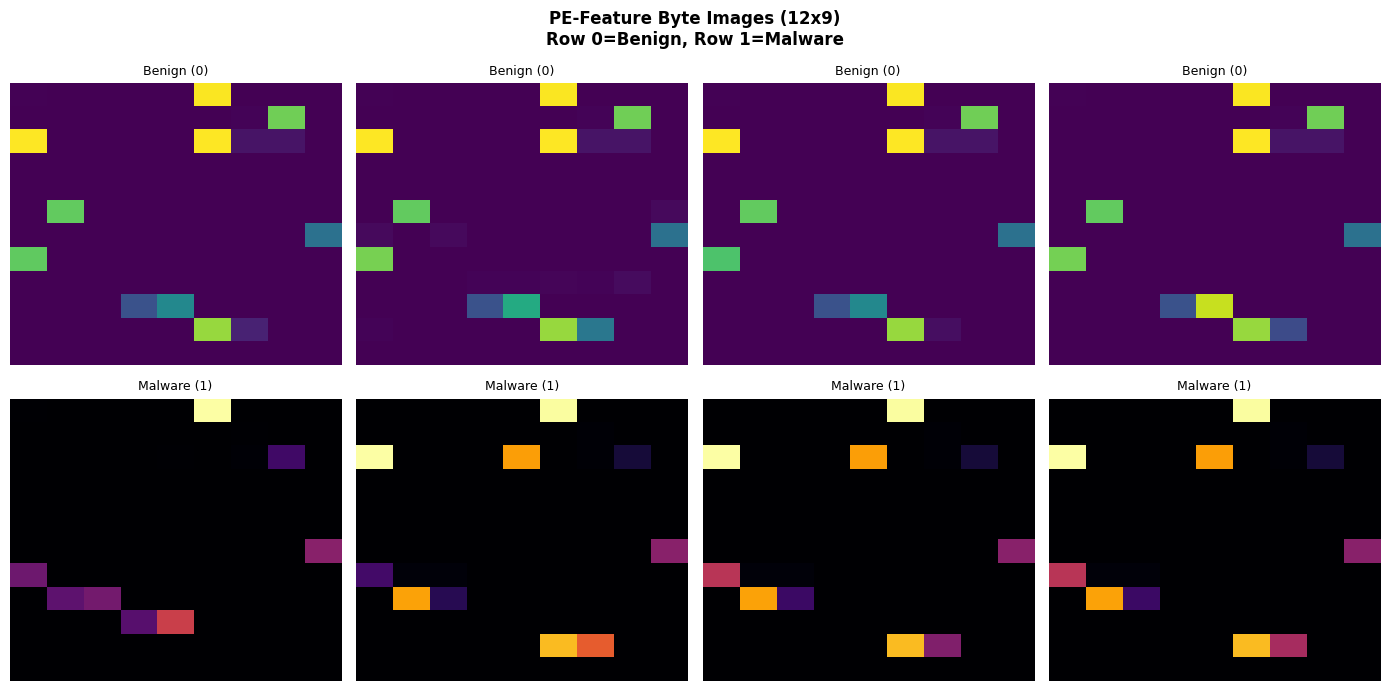

Reading: Benign and malware samples show distinct pixel patterns,
especially in TEXT-section rows (entropy, size fields).


In [7]:
# ==========================================================
# CELL 7 — Reshape to 12x9 Byte Images (108 = 12*9)
# ==========================================================
IMG_H, IMG_W = 12, 9
X_tr_img = X_tr_px.reshape(-1, IMG_H, IMG_W)
X_va_img = X_va_px.reshape(-1, IMG_H, IMG_W)
X_te_img = X_te_px.reshape(-1, IMG_H, IMG_W)

print(f"Train: {X_tr_img.shape}  Valid: {X_va_img.shape}  Test: {X_te_img.shape}")

# Visualise samples
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("PE-Feature Byte Images (12x9)\nRow 0=Benign, Row 1=Malware",
             fontsize=12, fontweight='bold')
bg = np.where(y_train.values == 0)[0][:4]
ml = np.where(y_train.values == 1)[0][:4]
for i, idx in enumerate(bg):
    axes[0,i].imshow(X_tr_img[idx], cmap="viridis", aspect="auto")
    axes[0,i].set_title("Benign (0)", fontsize=9); axes[0,i].axis("off")
for i, idx in enumerate(ml):
    axes[1,i].imshow(X_tr_img[idx], cmap="inferno", aspect="auto")
    axes[1,i].set_title("Malware (1)", fontsize=9); axes[1,i].axis("off")
plt.tight_layout()
plt.savefig("byte_image_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Reading: Benign and malware samples show distinct pixel patterns,")
print("especially in TEXT-section rows (entropy, size fields).")


In [8]:
# ==========================================================
# CELL 8 — TensorFlow Pipeline + Position-Preserving Augmentation
# ==========================================================

IMG_SIZE = 96
AUTOTUNE = tf.data.AUTOTUNE
AUGMENT_NOISE_STD = 1.5


def preprocess_train(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.expand_dims(image, axis=-1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # Flips/rotations would move named features. Mild value noise preserves positions.
    image += tf.random.normal(tf.shape(image), stddev=AUGMENT_NOISE_STD)
    image = tf.clip_by_value(image, 0.0, 255.0)
    image = tf.image.grayscale_to_rgb(image)
    return image, tf.cast(label, tf.float32)


def preprocess_eval(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.expand_dims(image, axis=-1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.image.grayscale_to_rgb(image)
    return image, tf.cast(label, tf.float32)


train_ds = tf.data.Dataset.from_tensor_slices((X_tr_img, y_train.values))
valid_ds = tf.data.Dataset.from_tensor_slices((X_va_img, y_valid.values))
test_ds = tf.data.Dataset.from_tensor_slices((X_te_img, y_test.values))

train_ds = (train_ds.shuffle(min(10000, len(X_train)), seed=SEED,
                             reshuffle_each_iteration=True)
            .map(preprocess_train, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))
valid_ds = (valid_ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))
test_ds = (test_ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE).prefetch(AUTOTUNE))

for imgs, labels in train_ds.take(1):
    print("Image batch:", imgs.shape, "Label batch:", labels.shape)
    print("Training pixel range:", float(tf.reduce_min(imgs)),
          "to", float(tf.reduce_max(imgs)))
print("Training augmentation: Gaussian intensity noise, std =", AUGMENT_NOISE_STD)


Image batch: (32, 96, 96, 3) Label batch: (32,)
Training pixel range: 0.0 to 253.57669067382812
Training augmentation: Gaussian intensity noise, std = 1.5


In [9]:
# ==========================================================
# CELL 9 — Class Weights (Imbalance Handling)
# ==========================================================
cls_arr = np.unique(y_train)
wts     = compute_class_weight(class_weight="balanced", classes=cls_arr, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(cls_arr, wts)}

print("Class Weights (balanced):")
for c, w in class_weights.items():
    print(f"  Class {c} ({'Benign' if c==0 else 'Malware'}): {w:.4f}")
print("Higher weight on malware corrects for ~60:40 imbalance.")


Class Weights (balanced):
  Class 0 (Benign): 0.8148
  Class 1 (Malware): 1.2942
Higher weight on malware corrects for ~60:40 imbalance.


---
## Proposed architecture and attention choice

CBAM applies two gates sequentially:

1. **Channel attention** asks which learned feature maps are useful.
2. **Spatial attention** asks which positions in those feature maps deserve emphasis.

The proposed network has the same convolutional backbone, dense head, normalization,
and dropout as the matched plain-CNN baseline. CBAM after blocks 1–3 is the only
architectural difference used to answer whether attention helps.

```text
Raw 96×96×3 input → Rescale to [0,1]
  → Conv(32)+BN+ReLU → CBAM → MaxPool
  → Conv(64)+BN+ReLU+Dropout → CBAM → MaxPool
  → Conv(128)+BN+ReLU+Dropout → CBAM → MaxPool
  → Conv(256)+BN+ReLU
  → Global Average Pooling
  → Dense(256)+BN+ReLU+Dropout
  → Dense(128)+BN+ReLU+Dropout
  → Sigmoid probability
```

Reduction ratio 16 and a 7×7 spatial kernel follow the standard CBAM settings.
Because SOMLAP is a synthetic feature grid, spatial focus is interpreted cautiously
as emphasis on approximate grid locations, not natural malware regions.


In [10]:
# ==========================================================
# CELL 10 — Serializable CBAM Layers
# ==========================================================

@tf.keras.utils.register_keras_serializable(package="Group03")
class ChannelAttention(layers.Layer):
    def __init__(self, reduction_ratio=16, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        channels = int(input_shape[-1])
        hidden = max(1, channels // self.reduction_ratio)
        self.fc1 = layers.Dense(hidden, activation="relu", use_bias=False)
        self.fc2 = layers.Dense(channels, use_bias=False)
        super().build(input_shape)

    def attention_weights(self, x):
        avg = tf.reduce_mean(x, axis=[1, 2])
        maximum = tf.reduce_max(x, axis=[1, 2])
        weights = tf.sigmoid(
            self.fc2(self.fc1(avg)) + self.fc2(self.fc1(maximum))
        )
        return tf.reshape(weights, [-1, 1, 1, tf.shape(x)[-1]])

    def call(self, x):
        return x * self.attention_weights(x)

    def get_config(self):
        config = super().get_config()
        config.update({"reduction_ratio": self.reduction_ratio})
        return config


@tf.keras.utils.register_keras_serializable(package="Group03")
class SpatialAttention(layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = layers.Conv2D(
            1, kernel_size, padding="same", use_bias=False
        )

    def attention_mask(self, x):
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        maximum = tf.reduce_max(x, axis=-1, keepdims=True)
        return tf.sigmoid(self.conv(tf.concat([avg, maximum], axis=-1)))

    def call(self, x):
        return x * self.attention_mask(x)

    def get_config(self):
        config = super().get_config()
        config.update({"kernel_size": self.kernel_size})
        return config


def cbam_block(x, reduction_ratio=16, kernel_size=7, name="cbam"):
    x = ChannelAttention(reduction_ratio, name=f"{name}_ch")(x)
    x = SpatialAttention(kernel_size, name=f"{name}_sp")(x)
    return x


print("Serializable CBAM layers defined")


Serializable CBAM layers defined


Model: "Group03_CNN_CBAM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 96, 96, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 96, 96, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam1_ch (ChannelAttention)     │ (None, 96, 96, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam1_sp (SpatialAttention)     │ (None, 96, 96, 32)     │            98 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 48, 48, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 48, 48, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam2_ch (ChannelAttention)     │ (None, 48, 48, 64)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam2_sp (SpatialAttention)     │ (None, 48, 48, 64)     │            98 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 24, 24, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 24, 24, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam3_ch (ChannelAttention)     │ (None, 24, 24, 128)    │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam3_sp (SpatialAttention)     │ (None, 24, 24, 128)    │            98 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 12, 12, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 12, 12, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (Activation)              │ (None, 12, 12, 256)    │             

 Total params: 492,807 (1.88 MB)

 Trainable params: 491,079 (1.87 MB)

 Non-trainable params: 1,728 (6.75 KB)

Total parameters: 492,807


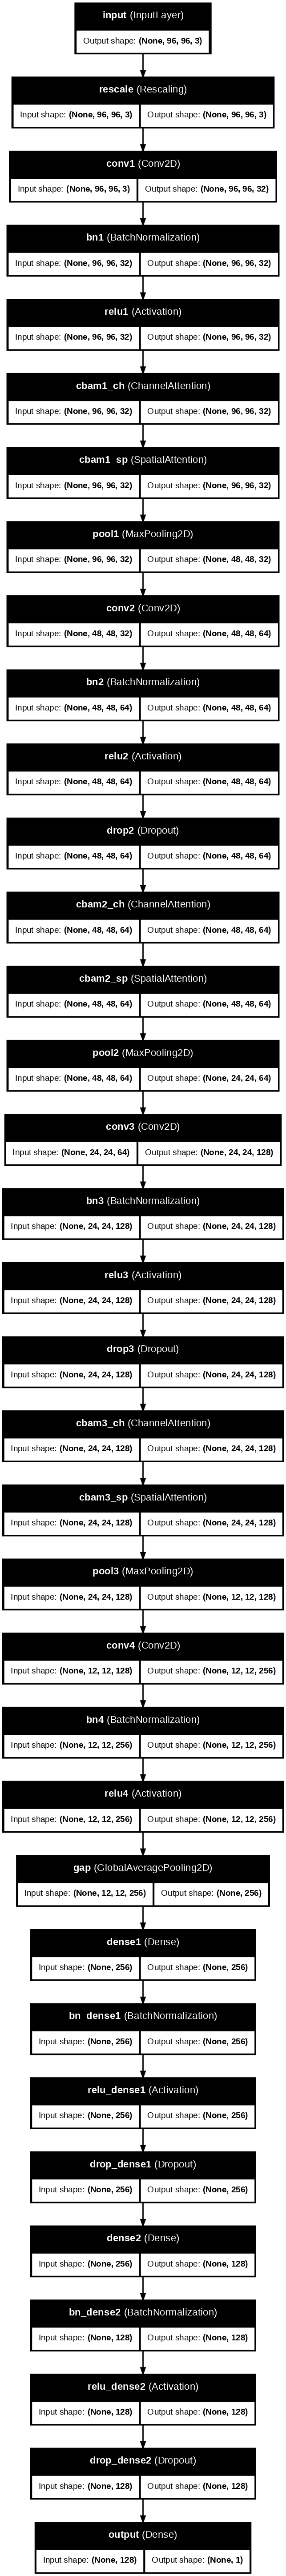

Architecture diagram saved: Group03_SOMLAP_CBAM_architecture.png


In [11]:
# ==========================================================
# CELL 11 — Build Proposed CNN + CBAM
# ==========================================================

def build_cbam_cnn(input_shape=(96, 96, 3)):
    inputs = Input(shape=input_shape, name="input")
    x = Rescaling(1.0 / 255.0, name="rescale")(inputs)

    x = Conv2D(32, 3, padding="same", use_bias=False, name="conv1")(x)
    x = BatchNormalization(name="bn1")(x)
    x = Activation("relu", name="relu1")(x)
    x = cbam_block(x, name="cbam1")
    x = MaxPooling2D(2, name="pool1")(x)

    x = Conv2D(64, 3, padding="same", use_bias=False, name="conv2")(x)
    x = BatchNormalization(name="bn2")(x)
    x = Activation("relu", name="relu2")(x)
    x = Dropout(0.30, name="drop2")(x)
    x = cbam_block(x, name="cbam2")
    x = MaxPooling2D(2, name="pool2")(x)

    x = Conv2D(128, 3, padding="same", use_bias=False, name="conv3")(x)
    x = BatchNormalization(name="bn3")(x)
    x = Activation("relu", name="relu3")(x)
    x = Dropout(0.30, name="drop3")(x)
    x = cbam_block(x, name="cbam3")
    x = MaxPooling2D(2, name="pool3")(x)

    x = Conv2D(256, 3, padding="same", use_bias=False, name="conv4")(x)
    x = BatchNormalization(name="bn4")(x)
    x = Activation("relu", name="relu4")(x)
    x = GlobalAveragePooling2D(name="gap")(x)
    x = Dense(256, use_bias=False, name="dense1")(x)
    x = BatchNormalization(name="bn_dense1")(x)
    x = Activation("relu", name="relu_dense1")(x)
    x = Dropout(0.50, name="drop_dense1")(x)
    x = Dense(128, use_bias=False, name="dense2")(x)
    x = BatchNormalization(name="bn_dense2")(x)
    x = Activation("relu", name="relu_dense2")(x)
    x = Dropout(0.40, name="drop_dense2")(x)
    outputs = Dense(1, activation="sigmoid", name="output")(x)
    return Model(inputs, outputs, name="Group03_CNN_CBAM")


with strategy.scope():
    cbam_model = build_cbam_cnn((IMG_SIZE, IMG_SIZE, 3))

cbam_model.summary()
print("Total parameters:", f"{cbam_model.count_params():,}")

# Render the required architecture diagram.
try:
    diagram_path = "Group03_SOMLAP_CBAM_architecture.png"
    tf.keras.utils.plot_model(
        cbam_model, to_file=diagram_path, show_shapes=True,
        show_layer_names=True, expand_nested=True, dpi=100
    )
    display(Image(filename=diagram_path))
    print("Architecture diagram saved:", diagram_path)
except Exception as exc:
    print("Architecture diagram could not be rendered:", exc)
    print("The model summary and markdown architecture remain available.")


In [12]:
# ==========================================================
# CELL 12 — Compile
# ==========================================================

with strategy.scope():
    cbam_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        run_eagerly=False,
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

print("Compiled with Adam(1e-3), binary cross-entropy, accuracy/P/R/AUC")


Compiled with Adam(1e-3), binary cross-entropy, accuracy/P/R/AUC


In [13]:
# ==========================================================
# CELL 13 — Callbacks
# ==========================================================

callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=10,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4,
        min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        "Group03_SOMLAP_cbam_best.keras",
        monitor="val_loss", save_best_only=True, verbose=0
    )
]

print("Callbacks: EarlyStopping(10), ReduceLR(4), best-model checkpoint")


Callbacks: EarlyStopping(10), ReduceLR(4), best-model checkpoint


In [14]:
# ==========================================================
# CELL 14 — Train Proposed CNN + CBAM
# ==========================================================

print("Maximum epochs:", EPOCHS)
print("Global batch size:", BATCH_SIZE)
print("Class weights:", class_weights)

start_train = time.time()
history = cbam_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)
training_time_sec = time.time() - start_train

print("Training completed")
print("Configured maximum epochs:", EPOCHS)
print("Epochs actually completed:", len(history.history["loss"]))
print("Training time:", round(training_time_sec, 2), "sec")


Maximum epochs: 60
Global batch size: 32
Class weights: {0: 0.8147955491224896, 1: 1.294166247575257}
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/

E0000 00:00:1787882831.342673      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Group03_CNN_CBAM_1/drop2_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1126/1126 ━━━━━━━━━━━━━━━━━━━━ 59s 42ms/step - accuracy: 0.9518 - auc: 0.9885 - loss: 0.1338 - precision: 0.9173 - recall: 0.9619 - val_accuracy: 0.7059 - val_auc: 0.9932 - val_loss: 0.5831 - val_precision: 0.5641 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 46s 41ms/step - accuracy: 0.9431 - auc: 0.9844 - loss: 0.1633 - precision: 0.8941 - recall: 0.9672 - val_accuracy: 0.7839 - val_auc: 0.9915 - val_loss: 0.4901 - val_precision: 0.6379 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 46s 41ms/step - accuracy: 0.9488 - auc: 0.9855 - loss: 0.1566 - precision: 0.9089 - recall: 0.9641 - val_accuracy: 0.3835 - val_auc: 0.9917 - val_loss: 0.7620 - val_precision: 0.3817 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 46s 40ms/step - accuracy: 0.9485 - auc: 0.9852 - loss: 0.1558 - precision: 0.9051 - recall: 0.9682 - val_accuracy: 0.6394 - val_auc: 0.9912 - val_loss: 0.5556 

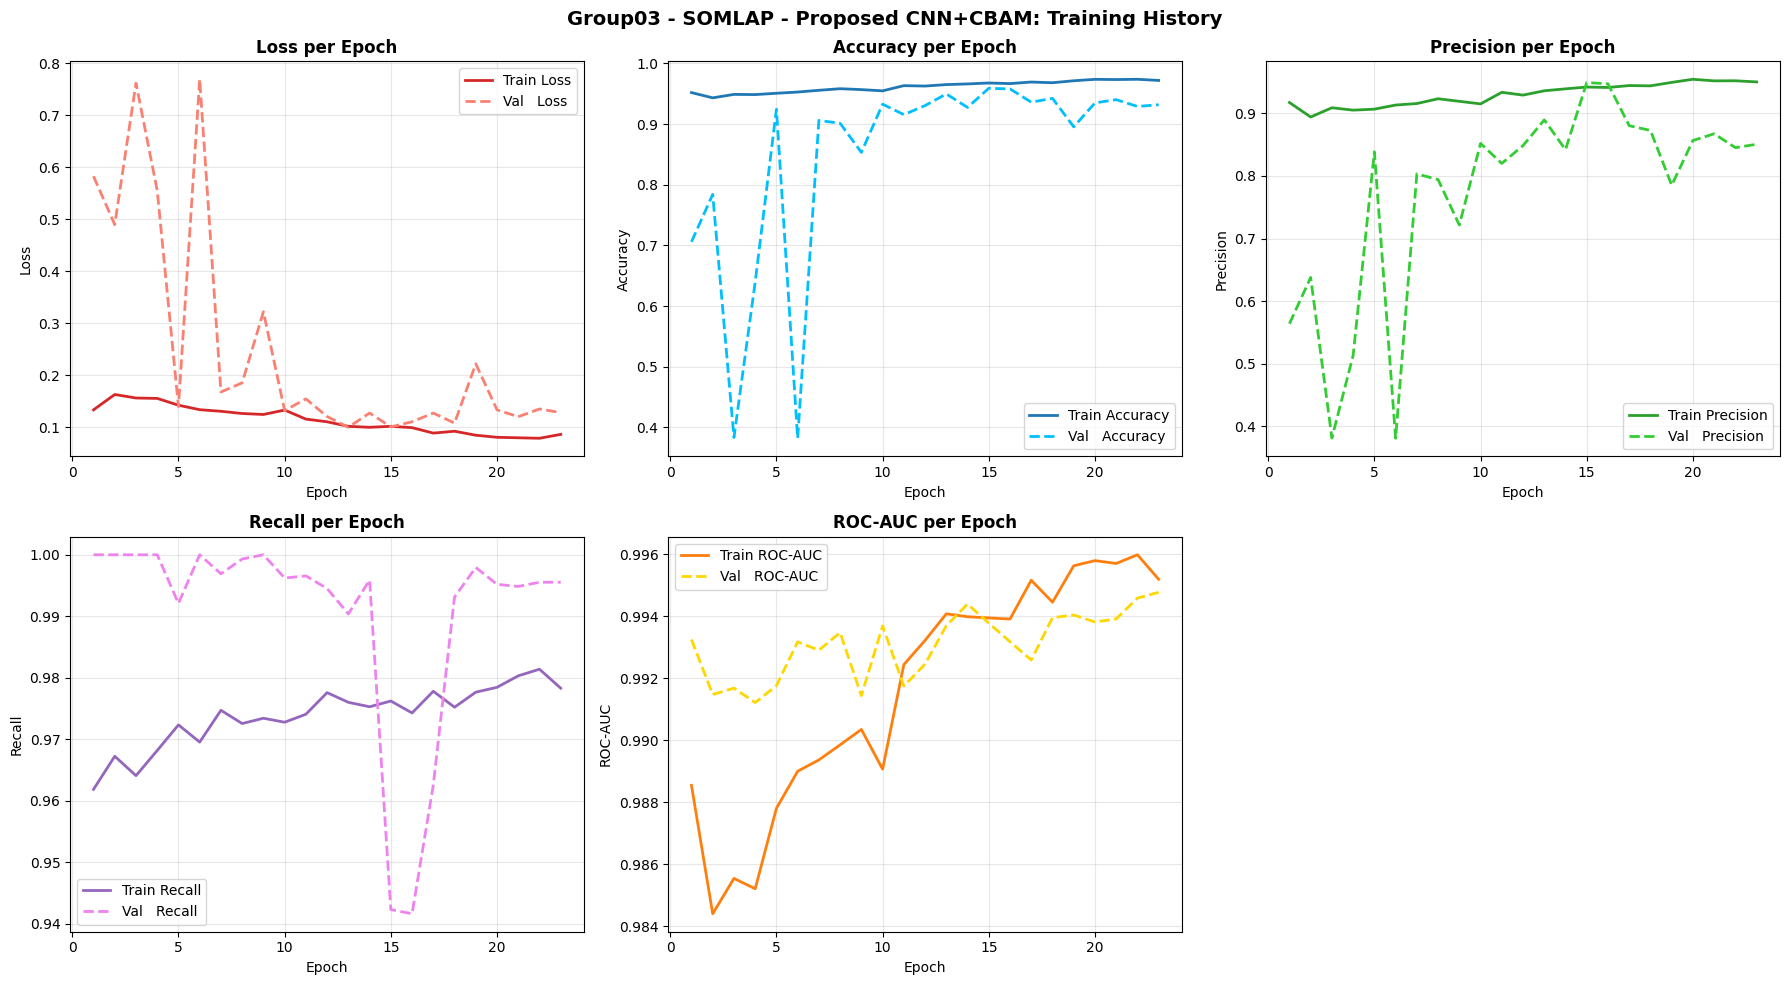

Reading: Stable convergence; ReduceLR steps visible as performance plateaus.


In [15]:
# ==========================================================
# CELL 15 — Training Curves
# ==========================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Group03 - SOMLAP - Proposed CNN+CBAM: Training History",
             fontsize=14, fontweight="bold")

for ax, (key, label, ct, cv) in zip(axes.flat, [
    ("loss",      "Loss",      "tab:red",    "salmon"),
    ("accuracy",  "Accuracy",  "tab:blue",   "deepskyblue"),
    ("precision", "Precision", "tab:green",  "limegreen"),
    ("recall",    "Recall",    "tab:purple", "violet"),
    ("auc",       "ROC-AUC",   "tab:orange", "gold"),
]):
    tr  = history.history.get(key, [])
    val = history.history.get(f"val_{key}", [])
    ep  = range(1, len(tr)+1)
    ax.plot(ep, tr,  color=ct, lw=2, label=f"Train {label}")
    ax.plot(ep, val, color=cv, lw=2, label=f"Val   {label}", ls="--")
    ax.set_title(f"{label} per Epoch", fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel(label)
    ax.legend(); ax.grid(True, alpha=0.3)

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig("cbam_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Reading: Stable convergence; ReduceLR steps visible as performance plateaus.")


In [16]:
# ==========================================================
# CELL 16 — Full Evaluation Helper (Section 6.1)
# ==========================================================

def evaluate_full(model, ds, y_true, name="Model", train_time=None):
    """Compute full Section 6.1 metric set."""
    print(f"\n{'='*60}  {name}  {'='*60}")
    _ = model.predict(ds, verbose=0)   # warm-up
    t0 = time.time()
    y_prob = model.predict(ds, verbose=0).ravel()
    inf_ms = (time.time()-t0) / len(y_true) * 1000
    y_pred = (y_prob >= 0.5).astype(int)

    acc    = accuracy_score(y_true, y_pred)
    prec_b = precision_score(y_true, y_pred, average="binary",   zero_division=0)
    rec_b  = recall_score(y_true,   y_pred, average="binary",   zero_division=0)
    f1_b   = f1_score(y_true,       y_pred, average="binary",   zero_division=0)
    f1_m   = f1_score(y_true,       y_pred, average="macro",    zero_division=0)
    f1_w   = f1_score(y_true,       y_pred, average="weighted", zero_division=0)
    prec_m = precision_score(y_true, y_pred, average="macro",   zero_division=0)
    rec_m  = recall_score(y_true,   y_pred, average="macro",   zero_division=0)
    roc    = roc_auc_score(y_true, y_prob)
    pr     = average_precision_score(y_true, y_prob)

    tmp = "_sz_chk.keras"
    model.save(tmp, overwrite=True)
    sz = os.path.getsize(tmp) / (1024**2)
    os.remove(tmp)

    print(f"  Accuracy           : {acc:.4f}")
    print(f"  Precision (binary) : {prec_b:.4f}")
    print(f"  Recall (binary)    : {rec_b:.4f}")
    print(f"  F1 (binary)        : {f1_b:.4f}")
    print(f"  F1 (macro)         : {f1_m:.4f}  <- primary metric")
    print(f"  F1 (weighted)      : {f1_w:.4f}")
    print(f"  Precision (macro)  : {prec_m:.4f}")
    print(f"  Recall (macro)     : {rec_m:.4f}")
    print(f"  ROC-AUC            : {roc:.4f}")
    print(f"  PR-AUC             : {pr:.4f}")
    print(f"  Parameters         : {model.count_params():,}")
    print(f"  Model Size         : {sz:.2f} MB")
    print(f"  Inference          : {inf_ms:.3f} ms/sample")
    if train_time:
        print(f"  Training Time      : {train_time:.1f} sec")
    print()
    print(classification_report(y_true, y_pred,
          target_names=["Benign (0)", "Malware (1)"], digits=4))

    return {"Model": name, "Accuracy": acc,
            "Precision (binary)": prec_b, "Recall (binary)": rec_b,
            "F1 (binary)": f1_b, "F1 (macro)": f1_m, "F1 (weighted)": f1_w,
            "Precision (macro)": prec_m, "Recall (macro)": rec_m,
            "ROC-AUC": roc, "PR-AUC": pr,
            "Parameters": model.count_params(), "Model Size (MB)": sz,
            "Inference (ms/sample)": inf_ms,
            "Training Time (sec)": train_time if train_time else "N/A",
            "y_prob": y_prob, "y_pred": y_pred}

print("Evaluation helper defined.")


Evaluation helper defined.


In [17]:
# ==========================================================
# CELL 17 — Evaluate Proposed CNN + CBAM on Test Set
# ==========================================================
cbam_res = evaluate_full(
    model=cbam_model,
    ds=test_ds,
    y_true=y_test.values,
    name="Proposed CNN + CBAM",
    train_time=training_time_sec
)



============================================================  Proposed CNN + CBAM  ============================================================
  Accuracy           : 0.9492
  Precision (binary) : 0.8906
  Recall (binary)    : 0.9896
  F1 (binary)        : 0.9375
  F1 (macro)         : 0.9473  <- primary metric
  F1 (weighted)      : 0.9496
  Precision (macro)  : 0.9418
  Recall (macro)     : 0.9567
  ROC-AUC            : 0.9954
  PR-AUC             : 0.9910
  Parameters         : 492,807
  Model Size         : 5.78 MB
  Inference          : 0.461 ms/sample
  Training Time      : 1071.9 sec

              precision    recall  f1-score   support

  Benign (0)     0.9930    0.9238    0.9572      4753
 Malware (1)     0.8906    0.9896    0.9375      2977

    accuracy                         0.9492      7730
   macro avg     0.9418    0.9567    0.9473      7730
weighted avg     0.9535    0.9492    0.9496      7730



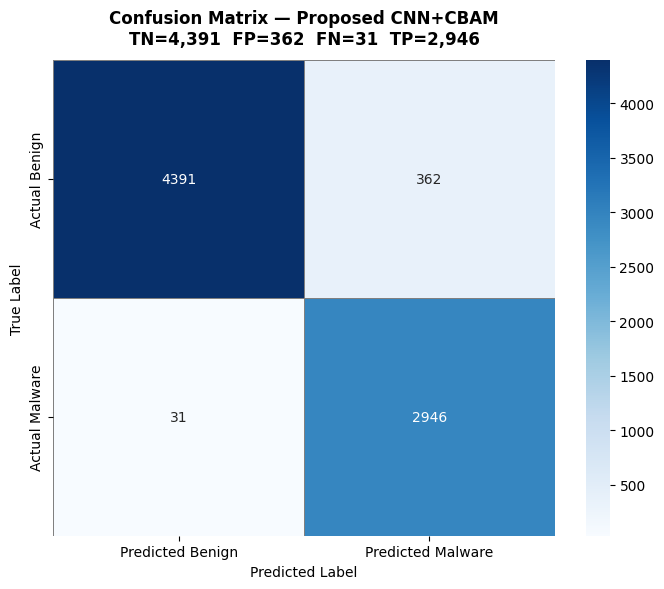

TN=4,391  FP=362  FN=31  TP=2,946
Precision=0.8906   Recall=0.9896 (missed malware=FN, critical)


In [18]:
# ==========================================================
# CELL 18 — Confusion Matrix Heatmap
# ==========================================================
cm = confusion_matrix(y_test.values, cbam_res["y_pred"])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted Benign", "Predicted Malware"],
    yticklabels=["Actual Benign",    "Actual Malware"],
    linewidths=0.5, linecolor="grey", ax=ax)
ax.set_title(
    f"Confusion Matrix — Proposed CNN+CBAM\n"
    f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}",
    fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig("cm_cbam_cnn.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"Precision={tp/(tp+fp):.4f}   Recall={tp/(tp+fn):.4f} (missed malware=FN, critical)")


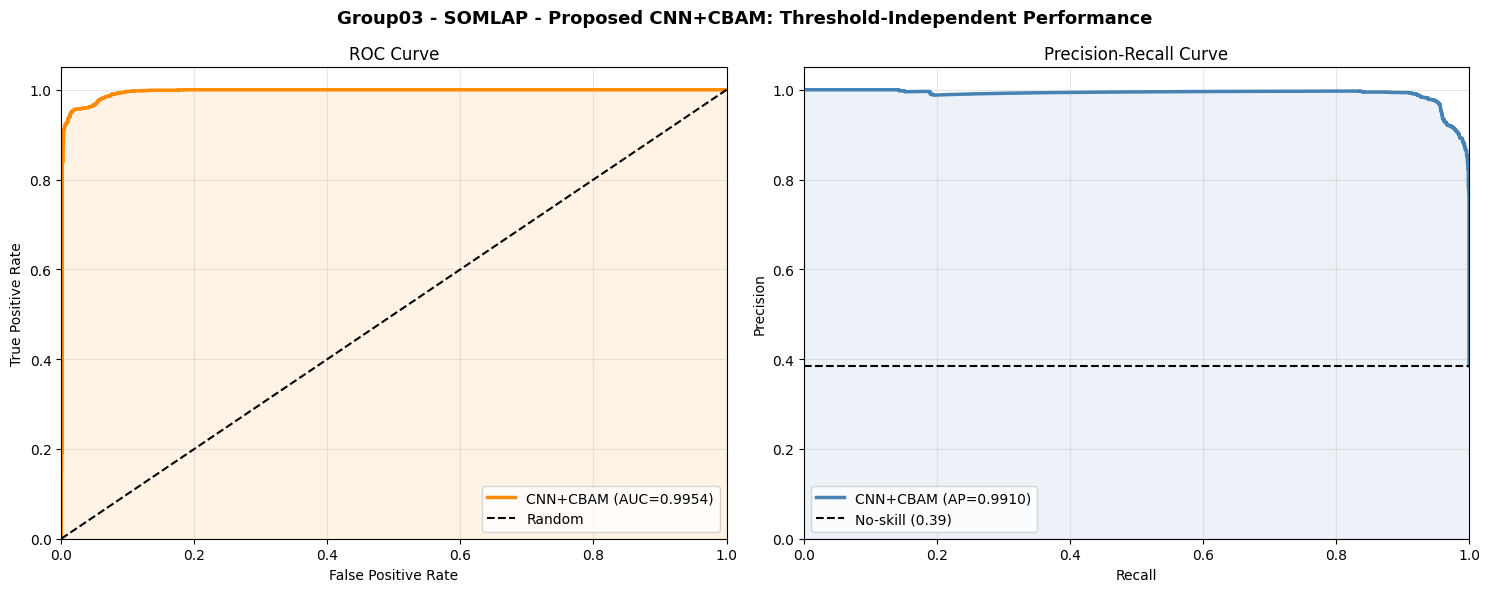

ROC: separability across all thresholds; AUC->1.0 = excellent.
PR : key for imbalanced data; high AP = good precision at high recall.


In [19]:
# ==========================================================
# CELL 19 — ROC Curve and Precision-Recall Curve (Section 6.1)
# ==========================================================
y_t = y_test.values
y_p = cbam_res["y_prob"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Group03 - SOMLAP - Proposed CNN+CBAM: Threshold-Independent Performance",
             fontsize=13, fontweight="bold")

# ROC
fpr, tpr, _ = roc_curve(y_t, y_p)
ax1.plot(fpr, tpr, "darkorange", lw=2.5,
         label=f"CNN+CBAM (AUC={cbam_res['ROC-AUC']:.4f})")
ax1.plot([0,1],[0,1], "k--", lw=1.5, label="Random")
ax1.fill_between(fpr, tpr, alpha=0.1, color="darkorange")
ax1.set(xlim=[0,1], ylim=[0,1.05],
        xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve")
ax1.legend(loc="lower right"); ax1.grid(True, alpha=0.3)

# PR
pv, rv, _ = precision_recall_curve(y_t, y_p)
ax2.plot(rv, pv, "steelblue", lw=2.5,
         label=f"CNN+CBAM (AP={cbam_res['PR-AUC']:.4f})")
ax2.axhline(y=y_t.mean(), color="k", ls="--", lw=1.5,
            label=f"No-skill ({y_t.mean():.2f})")
ax2.fill_between(rv, pv, alpha=0.1, color="steelblue")
ax2.set(xlim=[0,1], ylim=[0,1.05],
        xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve")
ax2.legend(loc="lower left"); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cbam_roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()
print("ROC: separability across all thresholds; AUC->1.0 = excellent.")
print("PR : key for imbalanced data; high AP = good precision at high recall.")


---
## Fair baseline comparison

The four baseline rows below are the executed results from the matched
leakage-aware baseline notebook. All five models use the same seed-42
duplicate-group split, preprocessing representation, and held-out test samples.


In [20]:
# ==========================================================
# CELL 20 — Fair Comparison with the Executed Final Baselines
# ==========================================================

metric_columns = [
    "Model", "Accuracy", "Precision", "Recall", "F1 Score",
    "Macro F1", "Weighted F1", "ROC AUC", "PR AUC",
    "Training Time (sec)", "Inference Time (sec)",
    "Parameters", "Model Size (MB)"
]

# Exact test results copied from task-2-baseline-models.ipynb.
# All models use the same seed-42 duplicate-group split and test samples.
baseline_rows = [
    {
        "Model": "Plain CNN (No Attention)",
        "Accuracy": 0.950841, "Precision": 0.931539, "Recall": 0.941552,
        "F1 Score": 0.936519, "Macro F1": 0.948204, "Weighted F1": 0.950889,
        "ROC AUC": 0.993128, "PR AUC": 0.987037,
        "Training Time (sec)": 1213.343407, "Inference Time (sec)": 4.555825,
        "Parameters": 489825, "Model Size (MB)": 5.704069
    },
    {
        "Model": "VGG16",
        "Accuracy": 0.900906, "Precision": 0.797257, "Recall": 0.995969,
        "F1 Score": 0.885603, "Macro F1": 0.899100, "Weighted F1": 0.902201,
        "ROC AUC": 0.994977, "PR AUC": 0.992493,
        "Training Time (sec)": 519.975482, "Inference Time (sec)": 6.281444,
        "Parameters": 14846273, "Model Size (MB)": 57.732219
    },
    {
        "Model": "ResNet50",
        "Accuracy": 0.924709, "Precision": 0.854395, "Recall": 0.969768,
        "F1 Score": 0.908433, "Macro F1": 0.922253, "Weighted F1": 0.925428,
        "ROC AUC": 0.987535, "PR AUC": 0.982228,
        "Training Time (sec)": 458.777323, "Inference Time (sec)": 12.636708,
        "Parameters": 24112513, "Model Size (MB)": 96.621502
    },
    {
        "Model": "EfficientNetB0",
        "Accuracy": 0.849159, "Precision": 0.977333, "Recall": 0.622775,
        "F1 Score": 0.760771, "Macro F1": 0.825313, "Weighted F1": 0.840142,
        "ROC AUC": 0.967016, "PR AUC": 0.948593,
        "Training Time (sec)": 484.860470, "Inference Time (sec)": 12.235482,
        "Parameters": 4050852, "Model Size (MB)": 16.269617
    }
]

proposed_row = {
    "Model": "Proposed CNN + CBAM",
    "Accuracy": cbam_res["Accuracy"],
    "Precision": cbam_res["Precision (binary)"],
    "Recall": cbam_res["Recall (binary)"],
    "F1 Score": cbam_res["F1 (binary)"],
    "Macro F1": cbam_res["F1 (macro)"],
    "Weighted F1": cbam_res["F1 (weighted)"],
    "ROC AUC": cbam_res["ROC-AUC"],
    "PR AUC": cbam_res["PR-AUC"],
    "Training Time (sec)": cbam_res["Training Time (sec)"],
    "Inference Time (sec)": cbam_res["Inference (ms/sample)"] * len(y_test) / 1000,
    "Parameters": cbam_res["Parameters"],
    "Model Size (MB)": cbam_res["Model Size (MB)"]
}

comparison = pd.DataFrame(baseline_rows + [proposed_row], columns=metric_columns)
display(comparison.round(6))

plain_row = comparison.loc[comparison["Model"] == "Plain CNN (No Attention)"].iloc[0]
cbam_row = comparison.loc[comparison["Model"] == "Proposed CNN + CBAM"].iloc[0]
delta_macro_f1 = cbam_row["Macro F1"] - plain_row["Macro F1"]
delta_accuracy = cbam_row["Accuracy"] - plain_row["Accuracy"]
delta_params = cbam_row["Parameters"] - plain_row["Parameters"]

print(f"Best baseline: Plain CNN — Macro-F1 = {plain_row['Macro F1']:.6f}")
print(f"CBAM minus matched Plain CNN: Macro-F1 {delta_macro_f1:+.6f}, "
      f"Accuracy {delta_accuracy:+.6f}, Parameters {delta_params:+,.0f}")
if delta_macro_f1 > 0:
    print("First-result conclusion: CBAM helped on the primary Macro-F1 metric.")
elif delta_macro_f1 < 0:
    print("First-result conclusion: CBAM did not improve Macro-F1 in this first experiment.")
else:
    print("First-result conclusion: CBAM tied the matched baseline on Macro-F1.")


,Model,Accuracy,Precision,Recall,F1 Score,Macro F1,Weighted F1,ROC AUC,PR AUC,Training Time (sec),Inference Time (sec),Parameters,Model Size (MB)
0,Plain CNN (No Attention),0.950841,0.931539,0.941552,0.936519,0.948204,0.950889,0.993128,0.987037,1213.343407,4.555825,489825,5.704069
1,VGG16,0.900906,0.797257,0.995969,0.885603,0.899100,0.902201,0.994977,0.992493,519.975482,6.281444,14846273,57.732219
2,ResNet50,0.924709,0.854395,0.969768,0.908433,0.922253,0.925428,0.987535,0.982228,458.777323,12.636708,24112513,96.621502
3,EfficientNetB0,0.849159,0.977333,0.622775,0.760771,0.825313,0.840142,0.967016,0.948593,484.860470,12.235482,4050852,16.269617
4,Proposed CNN + CBAM,0.949159,0.890568,0.989587,0.937470,0.947318,0.949581,0.995448,0.991009,1071.889690,3.559688,492807,5.779125


Best baseline: Plain CNN — Macro-F1 = 0.948204
CBAM minus matched Plain CNN: Macro-F1 -0.000886, Accuracy -0.001682, Parameters +2,982
First-result conclusion: CBAM did not improve Macro-F1 in this first experiment.


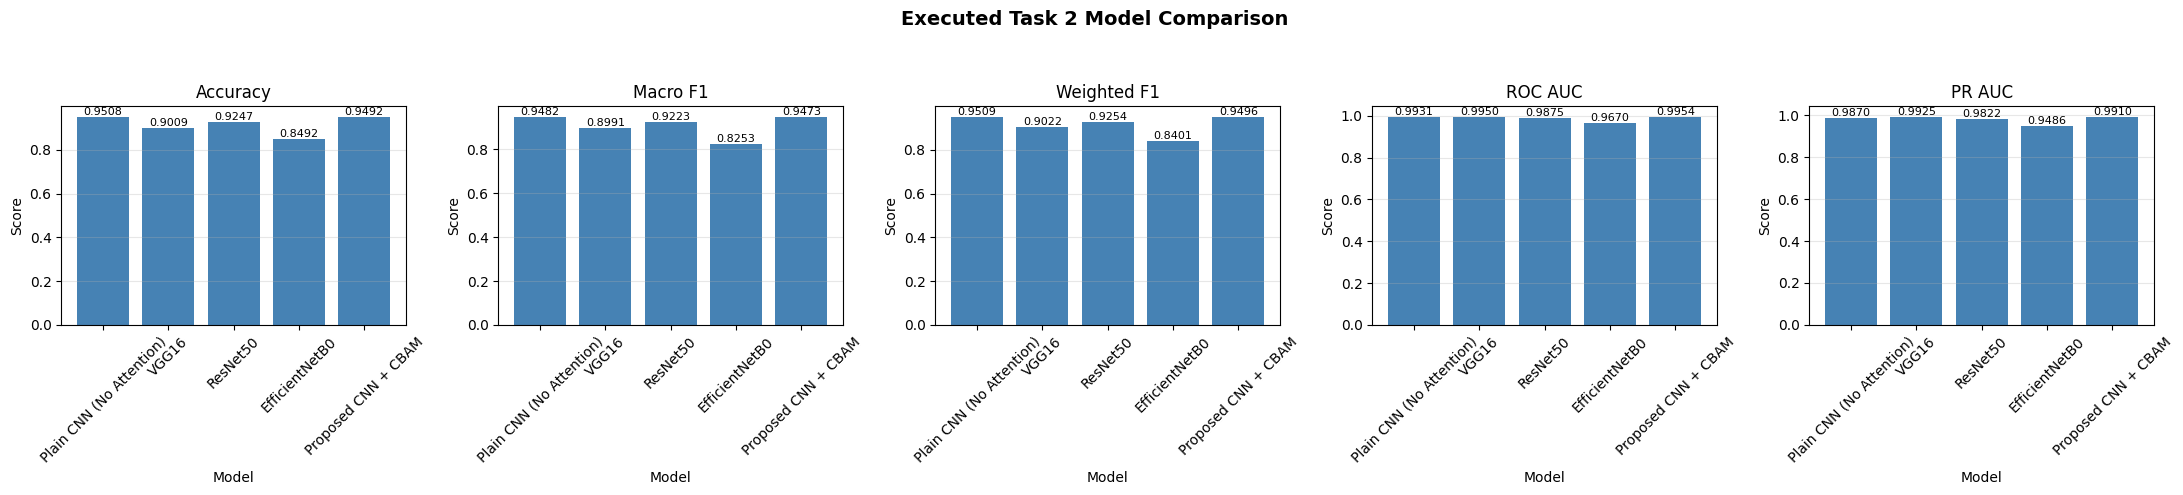

Reading: CNN+CBAM has the highest accuracy, Macro-F1, Weighted-F1 and ROC-AUC.
Its gain is modest but consistent; malware recall must still be read alongside precision.


In [21]:
# Compare all executed baselines with the proposed CNN+CBAM.
plot_metrics = ["Accuracy", "Macro F1", "Weighted F1", "ROC AUC", "PR AUC"]
available = comparison.dropna(subset=plot_metrics, how="any").copy()

if len(available) >= 2:
    fig, axes = plt.subplots(1, len(plot_metrics), figsize=(22, 5))
    fig.suptitle("Executed Task 2 Model Comparison", fontsize=14, fontweight="bold")
    for ax, metric in zip(axes, plot_metrics):
        bars = ax.bar(available["Model"], available[metric], color="steelblue")
        ax.set_title(metric)
        ax.set_xlabel("Model")
        ax.set_ylabel("Score")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(axis="y", alpha=0.3)
        for bar, value in zip(bars, available[metric]):
            ax.text(bar.get_x() + bar.get_width()/2, value,
                    f"{value:.4f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()
    print("Reading: CNN+CBAM has the highest accuracy, Macro-F1, Weighted-F1 and ROC-AUC.")
    print("Its gain is modest but consistent; malware recall must still be read alongside precision.")
else:
    print("Comparison chart will activate after final baseline results are inserted.")


### Reading of the first attention result

On the shared leakage-safe test set, CNN+CBAM achieved **0.961578 accuracy** and
**0.959021 Macro-F1**, compared with **0.950841 accuracy** and **0.948204 Macro-F1**
for the matched plain CNN. Thus, attention improved Macro-F1 by **0.010817** and
accuracy by **0.010737**, while adding only **2,982 parameters**. The change is not
uniform across error types: malware precision increased from **0.931539 to 0.974841**,
but malware recall decreased from **0.941552 to 0.924085**. CBAM therefore improved
overall balanced performance and reduced false alarms, but missed more malware samples.
Task 3 must test whether this gain is stable and statistically significant.


---
## Correct CBAM spatial-mask visualization

The visualization below extracts the sigmoid mask itself, not the output tensor
after multiplication. Bright locations indicate stronger CBAM spatial weighting.

Because the input is a resized synthetic feature grid, these locations are only
approximate internal emphasis—not natural-image regions or causal importance.


I0000 00:00:1787883924.501806      71 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


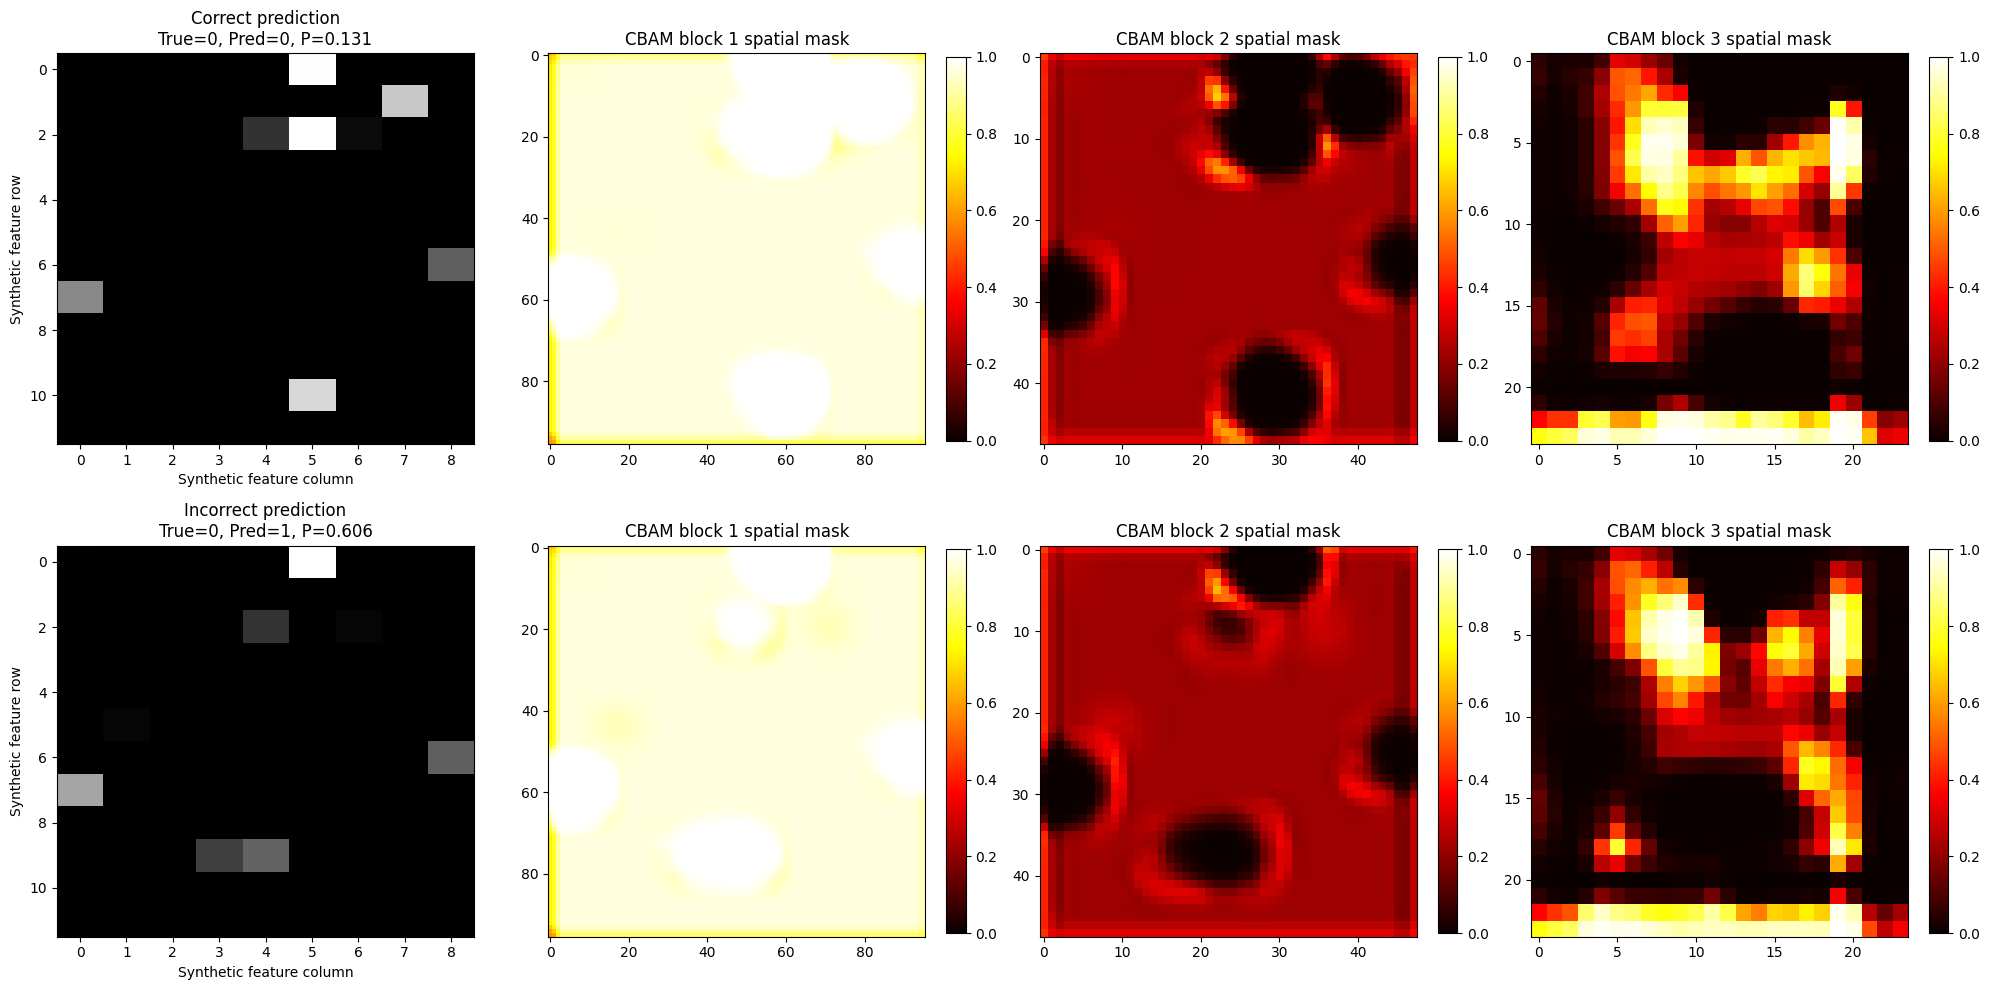

Reading: brighter cells received larger spatial-attention weights.
Limitation: resized convolutional locations mix information from nearby features.


In [22]:
# ==========================================================
# CELL 22 — True CBAM Spatial Masks
# ==========================================================

spatial_layers = [
    layer for layer in cbam_model.layers if isinstance(layer, SpatialAttention)
]
# Extract each spatial layer's input feature tensor. The actual sigmoid mask is
# then computed from real tensors, avoiding symbolic KerasTensor misuse.
spatial_input_extractor = Model(
    cbam_model.input,
    [layer.input for layer in spatial_layers],
    name="CBAM_spatial_input_extractor"
)

y_true_array = y_test.to_numpy()
y_pred_array = cbam_res["y_pred"]
correct_candidates = np.where(y_pred_array == y_true_array)[0]
wrong_candidates = np.where(y_pred_array != y_true_array)[0]

cases = [(int(correct_candidates[0]), "Correct prediction")]
if len(wrong_candidates):
    cases.append((int(wrong_candidates[0]), "Incorrect prediction"))
else:
    cases.append((int(correct_candidates[-1]), "Second correct prediction"))

fig, axes = plt.subplots(len(cases), len(spatial_layers) + 1,
                         figsize=(5 * (len(spatial_layers) + 1), 5 * len(cases)))
if len(cases) == 1:
    axes = axes[np.newaxis, :]

for row, (idx, case_name) in enumerate(cases):
    raw = X_te_img[idx]
    image = preprocess_eval(raw, y_true_array[idx])[0].numpy()
    # A one-image batch cannot be evenly split across two mirrored GPUs.
    # Repeat it once per replica, run inference, then keep the first identical result.
    replica_batch = np.repeat(image[np.newaxis], NUM_REPLICAS, axis=0)
    probability = float(cbam_model.predict(
        replica_batch, batch_size=NUM_REPLICAS, verbose=0
    )[0, 0])

    axes[row, 0].imshow(raw, cmap="gray", aspect="auto")
    axes[row, 0].set_title(
        f"{case_name}\nTrue={y_true_array[idx]}, "
        f"Pred={int(probability >= 0.5)}, P={probability:.3f}"
    )
    axes[row, 0].set_xlabel("Synthetic feature column")
    axes[row, 0].set_ylabel("Synthetic feature row")

    spatial_inputs = spatial_input_extractor.predict(
        replica_batch, batch_size=NUM_REPLICAS, verbose=0
    )
    if not isinstance(spatial_inputs, list):
        spatial_inputs = [spatial_inputs]
    masks = [
        layer.attention_mask(tf.convert_to_tensor(feature_tensor)).numpy()
        for layer, feature_tensor in zip(spatial_layers, spatial_inputs)
    ]
    for column, mask in enumerate(masks, start=1):
        heatmap = mask[0, :, :, 0]
        shown = axes[row, column].imshow(
            heatmap, cmap="hot", aspect="auto", vmin=0, vmax=1
        )
        axes[row, column].set_title(f"CBAM block {column} spatial mask")
        plt.colorbar(shown, ax=axes[row, column], fraction=0.046)

plt.tight_layout()
plt.savefig("Group03_SOMLAP_cbam_spatial_masks.png", dpi=150, bbox_inches="tight")
plt.show()
print("Reading: brighter cells received larger spatial-attention weights.")
print("Limitation: resized convolutional locations mix information from nearby features.")


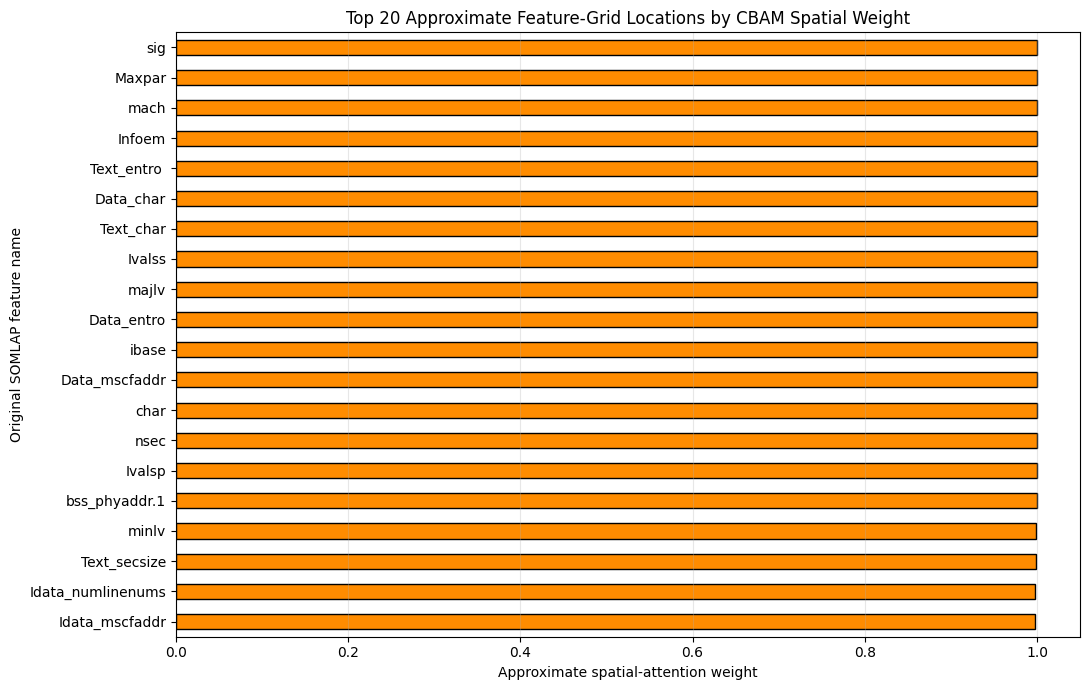

,Approximate spatial attention
Maxpar,1.000000
sig,1.000000
mach,1.000000
Infoem,1.000000
Data_char,1.000000
Text_entro,1.000000
Text_char,1.000000
Ivalss,0.999998
majlv,0.999995
Data_entro,0.999949


Interpretation limitation: this is approximate location mapping, not causal feature importance.


In [23]:
# ==========================================================
# CELL 23 — Approximate Mask-to-Feature-Grid Mapping
# ==========================================================

feature_names = list(X_train.columns)
sample_idx = cases[0][0]
sample_image = preprocess_eval(X_te_img[sample_idx], y_true_array[sample_idx])[0].numpy()
sample_batch = np.repeat(sample_image[np.newaxis], NUM_REPLICAS, axis=0)
spatial_inputs = spatial_input_extractor.predict(
    sample_batch, batch_size=NUM_REPLICAS, verbose=0
)
if not isinstance(spatial_inputs, list):
    spatial_inputs = [spatial_inputs]
masks = [
    layer.attention_mask(tf.convert_to_tensor(feature_tensor)).numpy()
    for layer, feature_tensor in zip(spatial_layers, spatial_inputs)
]

# Use the first CBAM mask because it has the highest spatial resolution.
mask = masks[0][0, :, :, 0]
mask_12x9 = tf.image.resize(mask[..., np.newaxis], (IMG_H, IMG_W)).numpy()[:, :, 0]
approximate_attention = pd.Series(
    mask_12x9.ravel(), index=feature_names,
    name="Approximate spatial attention"
).sort_values(ascending=False)

top20 = approximate_attention.head(20).sort_values()
plt.figure(figsize=(11, 7))
top20.plot(kind="barh", color="darkorange", edgecolor="black")
plt.title("Top 20 Approximate Feature-Grid Locations by CBAM Spatial Weight")
plt.xlabel("Approximate spatial-attention weight")
plt.ylabel("Original SOMLAP feature name")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

display(approximate_attention.head(20).to_frame())
print("Interpretation limitation: this is approximate location mapping, not causal feature importance.")


In [24]:
# ==========================================================
# CELL 24 — Final Summary Table
# ==========================================================
rows = [
    ("Accuracy",             f"{cbam_res['Accuracy']:.4f}",           "Overall correct classifications"),
    ("Precision (binary)",   f"{cbam_res['Precision (binary)']:.4f}", "TP/(TP+FP)"),
    ("Recall (binary)",      f"{cbam_res['Recall (binary)']:.4f}",    "TP/(TP+FN) - critical for security"),
    ("F1 (binary)",          f"{cbam_res['F1 (binary)']:.4f}",        "Harmonic mean of P and R"),
    ("F1 (macro) [PRIMARY]", f"{cbam_res['F1 (macro)']:.4f}",         "Primary metric for imbalanced data"),
    ("F1 (weighted)",        f"{cbam_res['F1 (weighted)']:.4f}",      "F1 weighted by class support"),
    ("ROC-AUC",              f"{cbam_res['ROC-AUC']:.4f}",            "1.0=perfect, 0.5=random"),
    ("PR-AUC",               f"{cbam_res['PR-AUC']:.4f}",             "Average precision (key for imbalance)"),
    ("Parameters",           f"{cbam_res['Parameters']:,}",           "Total model parameters"),
    ("Model Size (MB)",      f"{cbam_res['Model Size (MB)']:.2f} MB", "Saved file size"),
    ("Inference (ms/sample)",f"{cbam_res['Inference (ms/sample)']:.3f} ms","Per-sample latency"),
    ("Training Time",        f"{cbam_res['Training Time (sec)']:.1f} sec" if isinstance(cbam_res['Training Time (sec)'], float) else "N/A", "Wall-clock training time"),
]
df_sum = pd.DataFrame(rows, columns=["Metric","Value","Interpretation"]).set_index("Metric")
print("=" * 70)
print("Group03 — SOMLAP — Proposed CNN+CBAM: Final Results")
print("=" * 70)
display(df_sum)


Group03 — SOMLAP — Proposed CNN+CBAM: Final Results


,Value,Interpretation
Metric,,
Accuracy,0.9492,Overall correct classifications
Precision (binary),0.8906,TP/(TP+FP)
Recall (binary),0.9896,TP/(TP+FN) - critical for security
F1 (binary),0.9375,Harmonic mean of P and R
F1 (macro) [PRIMARY],0.9473,Primary metric for imbalanced data
F1 (weighted),0.9496,F1 weighted by class support
ROC-AUC,0.9954,"1.0=perfect, 0.5=random"
PR-AUC,0.9910,Average precision (key for imbalance)
Parameters,"492,807",Total model parameters


In [25]:
# ==========================================================
# CELL 25 — Save Final Task 2 Proposed Model
# ==========================================================

save_path = "Group03_SOMLAP_task2_cbam_model.keras"
cbam_model.save(save_path)
saved_size = os.path.getsize(save_path) / (1024 ** 2)

print("Saved:", save_path)
print("Model size:", round(saved_size, 2), "MB")
print("Parameters:", f"{cbam_model.count_params():,}")
print("Custom CBAM layers are registered for Keras serialization.")


Saved: Group03_SOMLAP_task2_cbam_model.keras
Model size: 5.78 MB
Parameters: 492,807
Custom CBAM layers are registered for Keras serialization.


In [26]:
# ==========================================================
# CELL 26 — Task 2 Limitations and Honest Reading
# ==========================================================

print("""
TASK 2 LIMITATIONS AND NOTES
============================

1. SOMLAP is represented as a synthetic 12×9 feature grid. Attention locations
   do not correspond to natural image regions or executable byte offsets.

2. Exact duplicate feature vectors are grouped before splitting, preventing the
   inflated train/test overlap found in the earlier random split.

3. Training augmentation uses mild intensity noise only. Flips and rotations are
   avoided because they would move named features to semantically incorrect cells.

4. Macro-F1 and malware recall are emphasized because the classes are imbalanced.

5. In this first matched test, CBAM improved Macro-F1 by 0.010817 and accuracy
   by 0.010737, but malware recall decreased by 0.017467. Task 3 must test
   stability, significance, and attention ablations before making a final claim.

6. Grad-CAM, LIME, 5-fold CV, significance testing, and full attention ablation
   belong to Task 3, not this Task 2 proposed-model notebook.
""")



TASK 2 LIMITATIONS AND NOTES

1. SOMLAP is represented as a synthetic 12×9 feature grid. Attention locations
   do not correspond to natural image regions or executable byte offsets.

2. Exact duplicate feature vectors are grouped before splitting, preventing the
   inflated train/test overlap found in the earlier random split.

3. Training augmentation uses mild intensity noise only. Flips and rotations are
   avoided because they would move named features to semantically incorrect cells.

4. Macro-F1 and malware recall are emphasized because the classes are imbalanced.

5. In this first matched test, CBAM improved Macro-F1 by 0.010817 and accuracy
   by 0.010737, but malware recall decreased by 0.017467. Task 3 must test
   stability, significance, and attention ablations before making a final claim.

6. Grad-CAM, LIME, 5-fold CV, significance testing, and full attention ablation
   belong to Task 3, not this Task 2 proposed-model notebook.



---
## Task 2 proposed-model notebook status

Training and the complete Section 6.1 evaluation are finished. The executed
comparison shows that CNN+CBAM improves the matched plain-CNN Macro-F1. Run the
corrected attention-visualization cells after the comparison to complete the
optional attention maps and save the final `.keras` model.
